# Part 1: Linear Regression

For this assignment, we will implement Linear Regression as learned in class. We will use an analytical approach and a gradient descent approach for this assignment, respectively.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
# Load the diabetes dataset
data = load_diabetes()
X = data.data # type: ignore
y = data.target # type: ignore
print("features:", X.shape)
print("labels:", y.shape)

# TODO: Split the dataset into training and testing sets
# You may use train_test_split in sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("training data:", X_train.shape, y_train.shape)
print("test data:",     X_test.shape,  y_test.shape)

features: (442, 10)
labels: (442,)
training data: (353, 10) (353,)
test data: (89, 10) (89,)


## Analytical Approach

For this part, you will use the analytical approach to implement a linear regression model, where the model weights are directly computed from the training data. Please refer to the course slides about how to obtain the weights.

In [3]:
# TODO: Create a bias vector and integrate it to the input matrix
bias = np.ones(shape=(X_train.shape[0], 1))
X_train_w_bias = np.hstack([X_train, bias])

bias = np.ones(shape=(X_test.shape[0], 1))
X_test_w_bias = np.hstack([X_test, bias])

# TODO: Compute the weights for the linear regression model
product = X_train_w_bias.T @ X_train_w_bias
product_inv = np.linalg.inv(product)

product_XT_y = X_train_w_bias.T @ y_train

weights_w_bias = product_inv @ product_XT_y

# TODO: Make predictions on the test data using the weights
y_pred = X_test_w_bias @ weights_w_bias 


# TODO: Evaluate the predicted reuslts using Mean Squared Error
summation = 0
for i in range(len(y_test)):
    summation += ((y_test[i] - y_pred[i])**2)
    
summation /= len(y_test)
mse = summation
print("Mean Squared Error:", mse)

Mean Squared Error: 2900.1936284934764


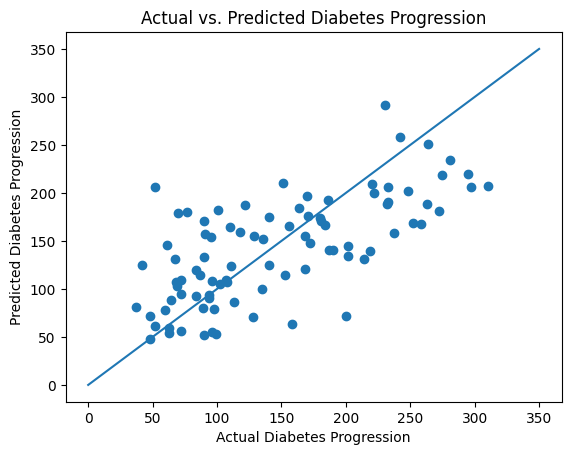

In [4]:
# TODO: Visualize the model's performance with the regression line
plt.scatter(x=y_test, y=y_pred)

# Drawing the ideal line
plt.plot([0, 350], [0, 350]) 

plt.xlabel("Actual Diabetes Progression")
plt.ylabel("Predicted Diabetes Progression")
plt.title("Actual vs. Predicted Diabetes Progression")
plt.show()

Weights: [-241.96436231  542.42875852  347.70384391 -931.48884588  518.06227698
  163.41998299  275.31790158  736.1988589    48.67065743  151.34560454]
Bias: 37.90402135007474


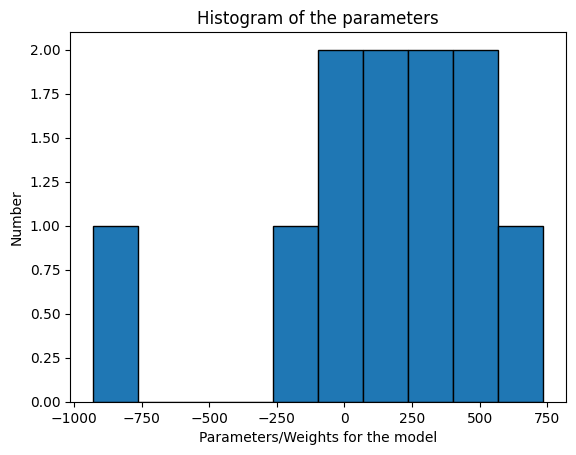

Greatest feature weight: 3
Smallest feature weight: 8
Bias: 37.90402135007474


In [5]:
# Separate and print the model weight parameters
# weights (coefficients)
weights = weights_w_bias[1::]
# bias( intercept)
bias = weights_w_bias[0]
print("Weights:", weights)
print("Bias:", bias)

# TODO: Plot a histogram chart to visualize the parameters
plt.hist(weights_w_bias, edgecolor='black')
plt.xlabel("Parameters/Weights for the model")
plt.ylabel("Number")
plt.title("Histogram of the parameters")
plt.show()


# TODO: Show the most and least important parameters
# First i take the absolute value of all the weights except the bias.
weights_abs = np.abs(weights)
# Greatest weight
max_weight = np.argmax(weights_abs)

# Smallest weight
min_weight = np.argmin(weights_abs)

print(f"Greatest feature weight: {max_weight}")
print(f"Smallest feature weight: {min_weight}")
print(f"Bias: {bias}")

## Gradient Descent Approach

For this part, you will use a gradient descent approach to implement a linear regression model for the same diabetes dataset. Please refer to the course slides about the gradient calculation and update.

In [6]:
# TODO: Determine learning rate, and training epochs
lr = 0.1          # Try options from 0.1 to 1e-4
num_steps = 20   # Try options from 5 to 20

# TODO: Initialize model parameters
weights = np.zeros((X_train.shape[1]))
bias = 0.0

In [7]:
# Model training
for step in range(num_steps):
  # TODO: Compute gradients on weights and bias
  y_pred = X_train @ weights + bias
  n = y_train.shape[0]

  error = y_pred - y_train

  grad_weights = (2 / n) * (X_train.T @ (error))
  grad_bias = (2 / n) * np.sum(error)

  # TODO: Apply gradient descent on the weights using learning rate
  # Find the gradient of the weights first
  nudge = lr * grad_weights
  weights -= nudge
  
  # Find the gradient of the bias.
  nudge = lr * grad_bias
  bias -= nudge
  
  sum = 0
  # TODO: Calculate Mean Squared Error during training

  # Have to make it square and then sum all the errors first.
  for i in range(error.shape[0]):
    sum += (error[i])**2
  sum /= error.shape[0]
  
  mse = sum
    
  print("Training error:", mse)

Training error: 29711.32294617564
Training error: 21193.17956999449
Training error: 15738.754462305391
Training error: 12245.1046367105
Training error: 10006.351392307479
Training error: 8570.735428002456
Training error: 7649.132743164782
Training error: 7056.505215639459
Training error: 6674.429228693179
Training error: 6427.114156749963
Training error: 6266.054301534793
Training error: 6160.206198579645
Training error: 6089.702136506297
Training error: 6041.826836963065
Training error: 6008.4425474454465
Training error: 5984.341112004107
Training error: 5966.189303731704
Training error: 5951.8538421837875
Training error: 5939.9694074907875
Training error: 5929.662171285676


In [8]:
# TODO: Make predictions on the test data
y_pred = X_test @ weights + bias

# TODO: Calculate Mean Squared Error for evaluation
errors = y_pred - y_test

# Have to make it square and then sum all the errors first.
for i in range(errors.shape[0]):
    sum += (errors[i])**2    
sum /= errors.shape[0]
mse = sum

# Print the evaluation metrics
print("Mean Squared Error:", mse)

Mean Squared Error: 5254.38362522608


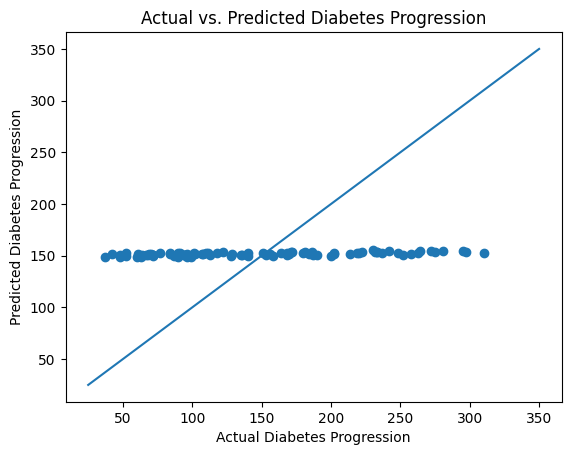

In [9]:
# TODO: Visualize the model's performance with the regression line
plt.plot([25, 350], [25, 350])
plt.scatter(y_test, y_pred)


plt.xlabel("Actual Diabetes Progression")
plt.ylabel("Predicted Diabetes Progression")
plt.title("Actual vs. Predicted Diabetes Progression")
plt.show()

Weights: [ 2.99684729  0.09640059  9.05817895  6.80261533  2.80114778  2.09561551
 -5.69022596  6.26417437  8.2892722   6.06457816]
Bias: 151.92264760796652


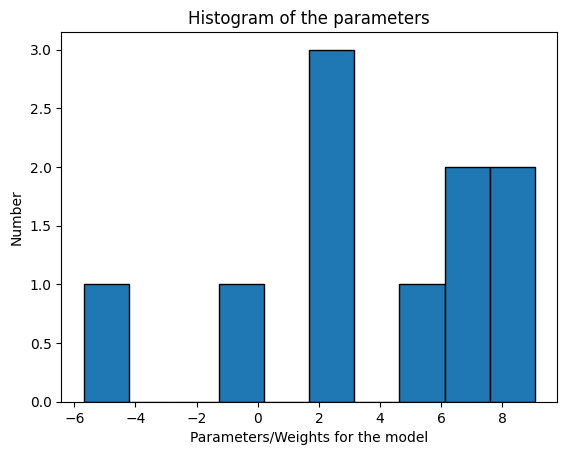

Greatest feature weight: 2
Smallest feature weight: 1
Bias: 151.92264760796652


In [10]:
# Print the model weight parameters
print("Weights:", weights)
print("Bias:", bias)

# TODO: Plot a histogram chart to visualize the parameters
plt.hist(weights, edgecolor='black')
plt.xlabel("Parameters/Weights for the model")
plt.ylabel("Number")
plt.title("Histogram of the parameters")
plt.show()

# TODO: Show the most and least important parameters
# First i take the absolute value of all the weights except the bias.
weights_abs = np.abs(weights)
# Greatest weight
max_weight = np.argmax(weights_abs)

# Smallest weight
min_weight = np.argmin(weights_abs)

print(f"Greatest feature weight: {max_weight}")
print(f"Smallest feature weight: {min_weight}")
print(f"Bias: {bias}")


## Use a new dataset california housing to train a linear regression model

* Load the dataset from fetch_california_housing [1 point]
* Train a linear regression model using gradient descent [4 points]
* Report the model's performance on the test set [2 points].
* For this dataset, how do the data split (try 20/80 and 50/50 training/test split ratios) and hyper-parameters (learning rate, training epochs) affect the outcome? Show and interpret your results [6 points].


**ANSWERS:**
- **QUESTION:** For this dataset, how do the data split (try 20/80 and 50/50 training/test split ratios) and hyper-parameters (learning rate, training epochs) affect the outcome? Show and interpret your results [6 points].
- **ANSWER:** 
        I trained this model with a 20/80 split training and also i trained it with 50/50 split training. The learning rate was set to 0.01 and epoch was set to 30. The 20/80 split performs alot better and gives a better fitting scatterplot result. This makes sense because the model has more data to train with so it's accuracy increases. And also the test data size is smaller so its easier to see better results. 
        For the learning rate, I tried with different rates ranging from 0.1 to 1e-8 but I honestly didnt see much of a difference. However, the epoch definitely seems to be a sensitive parameter on this model. Set it too high and the model kinda stops working, and if you set it too low the model's accuracy drops significantly. So i didnt want to push it past 30.
        

Training error: 5.629742323103177
Training error: 11472267185.436802
Training error: 5.1114885441343136e+19
Training error: 2.2774383424309995e+29
Training error: 1.0147191681718983e+39
Training error: 4.521110280230025e+48
Training error: 2.0143936181699138e+58
Training error: 8.975188388276186e+67
Training error: 3.9989208602752276e+77
Training error: 1.7817306283657252e+87
Training error: 7.938551781787495e+96
Training error: 3.537044454914408e+106
Training error: 1.5759402747416188e+116
Training error: 7.021646974501526e+125
Training error: 3.128514895185941e+135
Training error: 1.3939187607897533e+145
Training error: 6.21064491229209e+154
Training error: 2.7671706064652977e+164
Training error: 1.2329207793107567e+174
Training error: 5.4933138004019345e+183
Training error: 2.4475616776088402e+193
Training error: 1.0905181068048815e+203
Training error: 4.858834619567662e+212
Training error: 2.164867663635528e+222
Training error: 9.64562980221743e+231
Training error: 4.29763795008068

C:\Users\Khongor\AppData\Local\Temp\ipykernel_4828\1767649268.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


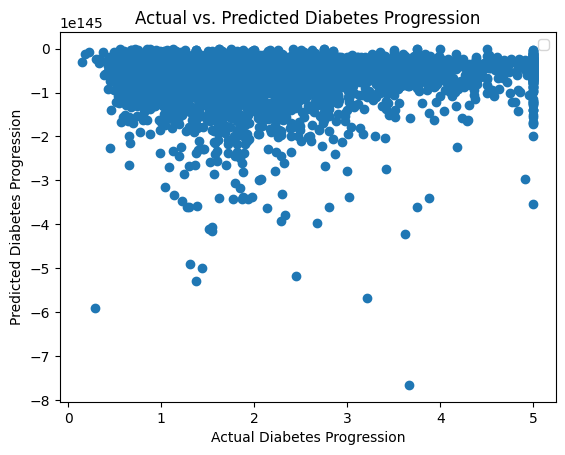

In [11]:
from sklearn.datasets import fetch_california_housing

# TODO: Load the dataset, train a linear regression model using gradient descent,
# and evaluate the model's performance on the test set
data = fetch_california_housing()
X = data.data # type: ignore
y = data.target # type: ignore

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Determine learning rate, and training epochs
lr = 0.01          # Try options from 0.1 to 1e-4
num_steps = 30   # Try options from 5 to 20

# TODO: Initialize model parameters
weights = np.zeros((X_train.shape[1]))
bias = 0.0

# Model training
for step in range(num_steps):
  # TODO: Compute gradients on weights and bias
  y_pred = X_train @ weights + bias
  n = y_train.shape[0]

  error = y_pred - y_train

  grad_weights = (2 / n) * (X_train.T @ (error))
  grad_bias = (2 / n) * np.sum(error)

  # TODO: Apply gradient descent on the weights using learning rate
  # Find the gradient of the weights first
  nudge = lr * grad_weights
  weights -= nudge
  
  # Find the gradient of the bias.
  nudge = lr * grad_bias
  bias -= nudge
  
  sum = 0
  # TODO: Calculate Mean Squared Error during training

  # Have to make it square and then sum all the errors first.
  for i in range(error.shape[0]):
    sum += (error[i])**2
  sum /= error.shape[0]
  
  mse = sum
    
  print("Training error:", mse)

  # TODO: Make predictions on the test data
y_pred = X_test @ weights + bias

# TODO: Calculate Mean Squared Error for evaluation
errors = y_pred - y_test

# Have to make it square and then sum all the errors first.
for i in range(errors.shape[0]):
    sum += (errors[i])**2    
sum /= errors.shape[0]
mse = sum

# Print the evaluation metrics
print("Mean Squared Error:", mse)

# TODO: Visualize the model's performance with the regression line
# plt.plot([25, 350], [25, 350])
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Diabetes Progression")
plt.ylabel("Predicted Diabetes Progression")
plt.title("Actual vs. Predicted Diabetes Progression")
plt.legend()
plt.show()


# Part 2: Getting Familiar with PyTorch

In this section, you will learn to use essential PyTorch functions.

Make sure you have the library installed. Run the cell below to check and install them if needed.

In [12]:
# Check and install required libraries
!pip install numpy pandas matplotlib scikit-learn torch --quiet

In [13]:
import torch
torch.manual_seed(0)

## PyTorch Tensor Construction

Let's start with some basic PyTorch tensor operations.

In [14]:
# Task 1: Create tensors with data
t1 = torch.ones((5, 3)) # A 2-D tensor with values of all ones and size of 5x3
t2 = torch.zeros((5, 3)) # A 2-D tensor with values of all zeros and size of 5x3
t3 = torch.eye(3)  # A 2-D tensor of an identity matrix with size of 3x3
t4 = torch.rand(3, 4) # A 2-D tensor with random values and size of 3x4
t5 = torch.arange(7) # A 1-D tensor with values from [0, 7) with size of 7.

print(t1)
print(t2)
print(t3)
print(t4)
print(t5)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
tensor([[0.4963, 0.7682, 0.0885, 0.1320],
        [0.3074, 0.6341, 0.4901, 0.8964],
        [0.4556, 0.6323, 0.3489, 0.4017]])
tensor([0, 1, 2, 3, 4, 5, 6])


In [15]:
import numpy as np

# Task 2: Convert tensors from existing data and to numpy arrays
t1 = torch.tensor([1,2,3,4]) # Create a tensor from Python list [1,2,3,4]
t2 = torch.tensor(np.array([1,2,3,4])) # Create a tensor from numpy array np.array([1,2,3,4])
t3 = t2.clone() # Clone a tensor from an existing tensor t2
t4 = t3.detach().cpu().numpy() # Convert tensor t3 to a numpy array
# I couldn't enable cuda and the tensor "t4" would always stay on my cpu. I don't if this is true but I did some digging and read somewhere that its because I have a radeon GPU?
# t5 = t4.to("cuda") # Move tensor t4 to GPU

print(t1)
print(t2)
print(t3)
print(t4)
print(t5)

tensor([1, 2, 3, 4])
tensor([1, 2, 3, 4])
tensor([1, 2, 3, 4])
[1 2 3 4]
tensor([0, 1, 2, 3, 4, 5, 6])


## Pivoting and Reshaping tensors
In the following section we cover common methods used to pivot and reshape tensors, namely:
1. Flatten
1. Squeeze
1. Reshape
1. Transpose

In [16]:
t = torch.rand(size=(3,4,5))
print(t)

# Task 3: Pivot and reshape tensors
t1 = t.flatten() # Flatten tensor t
t2 = t.unsqueeze(0) # Add a new dimension to t at dimension 0
t3 = t.squeeze() # Remove the dimension in t with size of 1
t4 = t.reshape((12,5)) # Reshape t to size of 12x5
t5 = t.transpose(0,1) # Transpose tensor t

print(t1)
print(t2)
print(t3)
print(t4)
print(t5)

tensor([[[0.0223, 0.1689, 0.2939, 0.5185, 0.6977],
         [0.8000, 0.1610, 0.2823, 0.6816, 0.9152],
         [0.3971, 0.8742, 0.4194, 0.5529, 0.9527],
         [0.0362, 0.1852, 0.3734, 0.3051, 0.9320]],

        [[0.1759, 0.2698, 0.1507, 0.0317, 0.2081],
         [0.9298, 0.7231, 0.7423, 0.5263, 0.2437],
         [0.5846, 0.0332, 0.1387, 0.2422, 0.8155],
         [0.7932, 0.2783, 0.4820, 0.8198, 0.9971]],

        [[0.6984, 0.5675, 0.8352, 0.2056, 0.5932],
         [0.1123, 0.1535, 0.2417, 0.7262, 0.7011],
         [0.2038, 0.6511, 0.7745, 0.4369, 0.5191],
         [0.6159, 0.8102, 0.9801, 0.1147, 0.3168]]])
tensor([0.0223, 0.1689, 0.2939, 0.5185, 0.6977, 0.8000, 0.1610, 0.2823, 0.6816,
        0.9152, 0.3971, 0.8742, 0.4194, 0.5529, 0.9527, 0.0362, 0.1852, 0.3734,
        0.3051, 0.9320, 0.1759, 0.2698, 0.1507, 0.0317, 0.2081, 0.9298, 0.7231,
        0.7423, 0.5263, 0.2437, 0.5846, 0.0332, 0.1387, 0.2422, 0.8155, 0.7932,
        0.2783, 0.4820, 0.8198, 0.9971, 0.6984, 0.5675, 0.8352

## Tensor Stack and Repeat
1. Cat
2. Stack
3. Repeat

In [17]:
tx = torch.rand(size=(3,4))
ty = torch.rand(size=(3,4))

# Task 4: Stack and repeat tensors
t1 = torch.cat([tx,ty],dim=1) # Concatenate tx and ty at dimension 1
t2 = torch.cat([tx,ty],dim=0) # Stack tx and ty at dimension 0
t3 = tx.repeat((3, 1)) # Repeat tx for 3 times at dimension 1

print(t1)
print(t2)
print(t3)

tensor([[0.6965, 0.9143, 0.9351, 0.9412, 0.5936, 0.4158, 0.4177, 0.2711],
        [0.5995, 0.0652, 0.5460, 0.1872, 0.6923, 0.2038, 0.6833, 0.7529],
        [0.0340, 0.9442, 0.8802, 0.0012, 0.8579, 0.6870, 0.0051, 0.1757]])
tensor([[0.6965, 0.9143, 0.9351, 0.9412],
        [0.5995, 0.0652, 0.5460, 0.1872],
        [0.0340, 0.9442, 0.8802, 0.0012],
        [0.5936, 0.4158, 0.4177, 0.2711],
        [0.6923, 0.2038, 0.6833, 0.7529],
        [0.8579, 0.6870, 0.0051, 0.1757]])
tensor([[0.6965, 0.9143, 0.9351, 0.9412],
        [0.5995, 0.0652, 0.5460, 0.1872],
        [0.0340, 0.9442, 0.8802, 0.0012],
        [0.6965, 0.9143, 0.9351, 0.9412],
        [0.5995, 0.0652, 0.5460, 0.1872],
        [0.0340, 0.9442, 0.8802, 0.0012],
        [0.6965, 0.9143, 0.9351, 0.9412],
        [0.5995, 0.0652, 0.5460, 0.1872],
        [0.0340, 0.9442, 0.8802, 0.0012]])


## Mathematical Operations
1. Point-wise/element-wise operations
1. Redution operations
1. Vector/Matrix operations

In [18]:
tx = torch.rand(size=(3,4))
ty = torch.rand(size=(3,4))
tz = torch.randn(4)

# Task 5: Math operations
t1 = tx*ty # Element-wise multiplication of tx and ty
t2 = tx@tz # Matrix multiplication of tx and tz
t3 = ty.sum(axis=1) # Calculate the sum of ty along dimension 1

print(t1)
print(t2)
print(t3)

tensor([[0.3542, 0.3477, 0.0325, 0.1690],
        [0.1899, 0.7981, 0.2376, 0.0293],
        [0.0089, 0.2566, 0.0707, 0.0707]])
tensor([0.5737, 1.3097, 0.5171])
tensor([2.1394, 2.0704, 2.0897])


## Autograd
(Some of the content is borrowed from the PyTorch website on autograd: https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html)
`torch.autograd` is PyTorch’s automatic differentiation engine that computes gradients.

In [19]:
# Task 6.1: Compute gradient for scalar inputs
x = torch.tensor([2.], requires_grad=True)
y = x ** 2


# TODO - compute the gradient
y.backward()


print(x.grad)
print(2*x == x.grad)

# Task 6.2: Compute gradient for vectors
x = torch.tensor([2., 3.], requires_grad=True)
y = x ** 2

# TODO - compute the gradient
y.sum().backward()

print(x.grad)
print(2*x == x.grad)

tensor([4.])
tensor([True])
tensor([4., 6.])
tensor([True, True])


`torch.autograd` tracks operations on all tensors which have their `requires_grad` flag set to `True`.
The output tensor of an operation will require gradients even if only a single input tensor has `requires_grad=True`.

In [20]:
x = torch.rand(5, 5)
y = torch.rand(5, 5)
z = torch.rand((5, 5), requires_grad=True)

a = x + y
b = x + z

# Task 6.3: Check the gradients of a and b
a_grad = a.requires_grad
b_grad = b.requires_grad
print(f"Does `a` require gradients?: {a_grad}")
print(f"Does `b` require gradients?: {b_grad}")

Does `a` require gradients?: False
Does `b` require gradients?: True


##Understand dataset creation

Write down what functions in torch.utils.data can be used to create a dataset from tensors and load each batch of data for training and testing. (reference https://docs.pytorch.org/docs/stable/data.html)

ANSWER: DataLoader, TensorDataset, random_split

##Understand PyTorch models
Write down what basic torch.nn function can be used for a linear model. (reference https://docs.pytorch.org/docs/stable/nn.html)

ANSWER: nn.Identity, nn.Linear, nn.Bilinear, nn.lazylinear

##Understand optimizers
Write down at least two optimizers in torch.optim that are useful to update model weight parameters. (reference https://docs.pytorch.org/docs/main/optim.html)


ANSWER: optimizer.step(), torch.optim.Optimizer.add_param_group()

##Understand loss function
Write down two loss functions in torch.nn that can be used for binary classification. (reference https://docs.pytorch.org/docs/stable/nn.html)

ANSWER: nn.L1Loss, nn.MSELoss